# Predict


In [1]:
import geopandas as gpd
import rasterio as rio
import numpy as np

import gcsfs
import geoutils as gu
import joblib
import sys
sys.path.append("/home/jovyan/marint-naturkart-niva")
import subkart


In [3]:
gdf = gpd.read_parquet("gs://niva-geodata/MarintNaturKart/Basisdata_15_More_og_Romsdal_25833_Dybdedata_Dybdeareal.geo.parquet")
gdf = subkart.features.depth_preprocess(gdf)
crs = gdf.crs

In [4]:
marine_vanntyper = gpd.read_parquet("gs://niva-geodata/MarintNaturKart/mdir/NyTypologi2022.geo.parquet").to_crs(gdf.crs)
marine_vanntyper = subkart.features.marine_vanntyper_preprocess(marine_vanntyper)
minx, miny, maxx, maxy = gdf.total_bounds
marine_vanntyper = marine_vanntyper.cx[minx:maxx, miny:maxy]

## Predict for AOI

In [5]:
gdf_bunn_moere = gpd.read_file("https://storage.googleapis.com/niva-geodata/MarintNaturKart/bunn_in_kommuner_sea.geojson")
gdf_clip = gdf_bunn_moere.to_crs(gdf.crs)

vec_clip = gu.Vector(gdf_clip)

In [6]:

clipped_marine_vanntyper = gdf_clip.overlay(marine_vanntyper)

In [7]:
clipped_gdf = gdf_clip.overlay(gdf)

In [9]:
features, valid_attrs, out_shape, transform = subkart.features.build_basis_raster(clipped_gdf, clipped_marine_vanntyper, valid_mask=None,res=25, dtype=np.float16)

Processing depth...


/home/kim/work/marint-naturkart-nivaR/.venv/lib/python3.11/site-packages/geoutils/raster/raster.py:1822: UserWarning: Setting default nodata -99999 to mask non-finite values found in the array, as no nodata value was defined.
  warnings.warn(


Processing slope...


/home/kim/work/marint-naturkart-nivaR/.venv/lib/python3.11/site-packages/geoutils/raster/raster.py:1822: UserWarning: Setting default nodata -99999 to mask non-finite values found in the array, as no nodata value was defined.
  warnings.warn(


Processing compactness...


/home/kim/work/marint-naturkart-nivaR/.venv/lib/python3.11/site-packages/geoutils/raster/raster.py:1822: UserWarning: Setting default nodata -99999 to mask non-finite values found in the array, as no nodata value was defined.
  warnings.warn(


Processing convexity...


/home/kim/work/marint-naturkart-nivaR/.venv/lib/python3.11/site-packages/geoutils/raster/raster.py:1822: UserWarning: Setting default nodata -99999 to mask non-finite values found in the array, as no nodata value was defined.
  warnings.warn(


Processing marine types...
Stacking feature arrays...


In [11]:
X = features

In [ ]:
fs = gcsfs.GCSFileSystem()
with fs.open("gs://niva-geodata/MarintNaturKart/classifier.joblib", "rb") as f:
    classifier = joblib.load(f)

/usr/lib64/python3.11/pickle.py:1718: UserWarning: [06:53:57] WARNING: /__w/xgboost/xgboost/src/collective/../data/../common/error_msg.h:83: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  setstate(state)


In [13]:
Y_pred = classifier.predict(X)

In [14]:
pred_map = np.full(out_shape, np.nan, dtype=np.float32)
pred_map[valid_attrs] = Y_pred.astype(np.float32)

In [15]:

pred_raster = gu.Raster.from_array(pred_map, transform=transform, crs=crs)

/home/kim/work/marint-naturkart-nivaR/.venv/lib/python3.11/site-packages/geoutils/raster/raster.py:1822: UserWarning: Setting default nodata -99999 to mask non-finite values found in the array, as no nodata value was defined.
  warnings.warn(


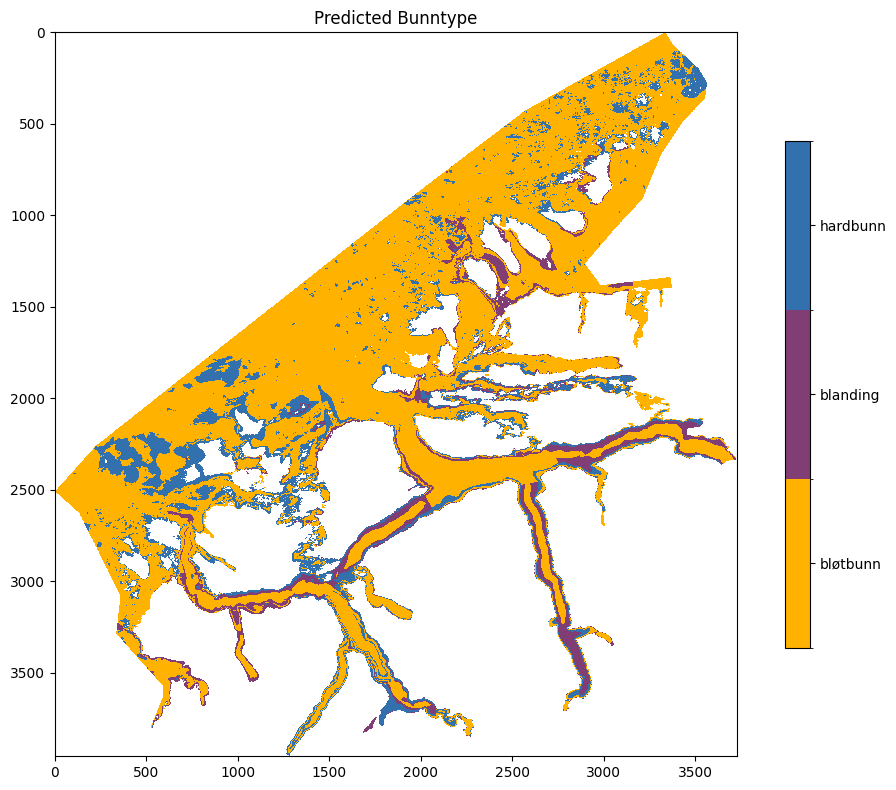

In [16]:
subkart.utils.plot_prediction_raster(pred_raster)

# Vectorize output

In [17]:
pred_vec = pred_raster.polygonize()

/home/kim/work/marint-naturkart-nivaR/.venv/lib/python3.11/site-packages/geoutils/interface/raster_vector.py:102: RuntimeWarning: invalid value encountered in cast
  shapes(source_raster.data.astype(final_dtype), mask=bool_msk, transform=source_raster.transform)


In [18]:
# Map raster_value (0/1) to BunnType using existing mapping_values
reverse_map = {v: k for k, v in subkart.labelling.BUNNTYPE_MAPPING.items()}
pred_vec["BunnType"] = pred_vec["raster_value"].map(reverse_map)

pred_vec["BunnType"]

0        fastbunn
1        fastbunn
2        fastbunn
3        fastbunn
4        fastbunn
           ...   
12322     løsbunn
12323     løsbunn
12324    fastbunn
12325     løsbunn
12326    fastbunn
Name: BunnType, Length: 12327, dtype: object

In [21]:
gdf_final = pred_vec.ds.to_crs("EPSG:25833")

In [22]:
fname = subkart.utils.to_filename(f"nisjedata-substrat-{classifier.__class__.__name__.lower()}", "moere-og-romsdal", "latest", gdf_final.crs.to_epsg())
gdf_final = gdf_final.drop(columns=["depth_range", "class"], errors="ignore")
gdf_final.to_file(f"{fname}.geojson", driver="GeoJSON")